# From raw CML signals to a rainfall map, end to end

One day of the OpenMRG network (Gothenburg, 28 July 2015, the Torslanda
convective event) taken through every stage of the pipeline:

1. **pull** the data - the curated OpenSense example subset, ~27 MB
2. **look** at the three sensor geometries with `poligrain`
3. **retrieve** rain from received and transmitted power, step by step
4. **score** the retrieval against radar and gauges on a like-for-like support
5. **improve** it with the OpenSense ecosystem's own wet/dry and wet-antenna
   methods, and measure the improvement
6. **map** it, alone and merged with radar, with `mergeplg`

Every function used here lives in `core/opensense/`, so the same calls work on
the full Zenodo archives, on OpenRainER and on OpenMesh. Runs in about a
minute, offline once the subset is cached.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import poligrain as plg
import xarray as xr

from core import viz_style as vs
from core.opensense import evaluation as ev
from core.opensense import example_data
from core.opensense import retrieval as rt
from core.opensense import wet_dry

# the merge wrapper is project code, not core
sys.path.insert(0, str(Path.cwd().parent / "src"))
import merging

import logging
vs.use_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

## 1. Pull the data

`example_data.load` downloads on first use (resumable, size-checked), caches
under `dataset/open_datasets/_example_subsets/`, and **normalizes on load**:
units become km / GHz / mm h⁻¹ whatever the file declared, polarization is
spelled one way, and everything gets projected coordinates.

`time=` selects a window before reading. The 8-day CML file is 1.2 GB in
memory; one day of it is 150 MB.

In [2]:
for key, spec in example_data.DATASETS.items():
    print(f"{key:11s} {spec.crs}  subsets: {', '.join(spec.subsets)}")

data = example_data.load("openmrg", "8d", time=slice("2015-07-28T06", "2015-07-28T23"))   # prints what it fetched or found cached
cml, radar, gauges = data["cml"], data["radar"], data["gauge_municipal"]
{name: dict(ds.sizes) for name, ds in data.items()}

openmrg     EPSG:32632  subsets: 8d, 5min_2h
openrainer  EPSG:32632  subsets: 8d
openmesh    EPSG:32618  subsets: 1d, 1w, 20d
ams_pws     EPSG:32631  subsets: full_period


  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


{'cml': {'sublink_id': 2, 'cml_id': 364, 'time': 6480},
 'radar': {'time': 216, 'y': 48, 'x': 37},
 'gauge_municipal': {'id': 10, 'time': 1080},
 'gauge_smhi': {'id': 1, 'time': 72}}

The full published records go through `core.opensense.fetch` instead (from the
repo root; Zenodo, md5-verified, resumable):

```bash
python -m core.opensense.fetch --list
python -m core.opensense.fetch --dataset openmrg
```

## 2. Three sensors, three geometries

A link measures a **path average**, a radar pixel an **area average**, a gauge a
**point**. `poligrain` plots all three on one map; its metadata plots show
what the network can physically measure - short, low-frequency links cannot
resolve light rain at all.

Text(0, 0.5, 'latitude')

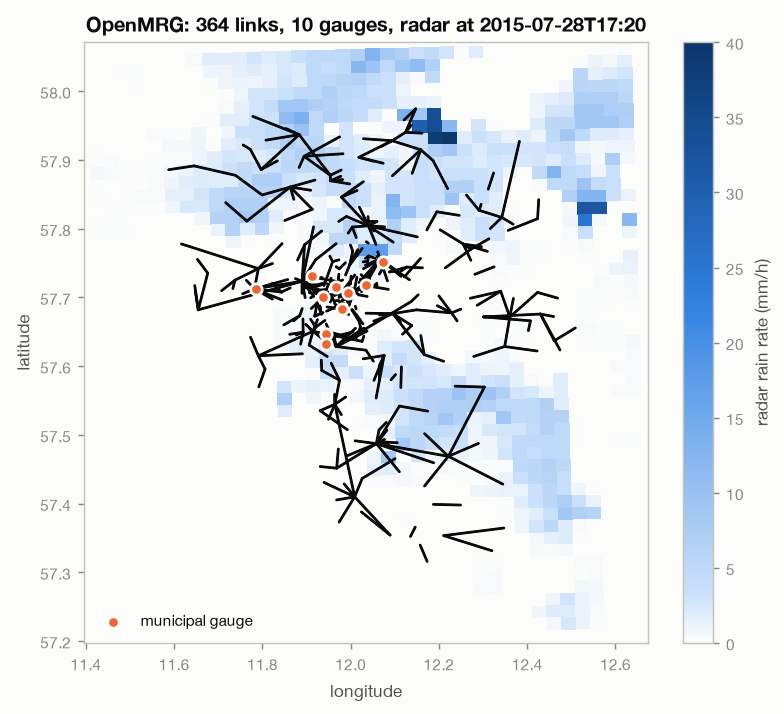

In [3]:
gauge_rate = (gauges.rainfall_amount * 60).transpose("time", "id")   # mm/min -> mm/h
t_peak = radar.R.sum(("x", "y")).argmax("time")

fig, ax = plt.subplots(figsize=(7, 6))
plg.plot_map.plot_plg(da_grid=radar.R.isel(time=t_peak), use_lon_lat=True, ax=ax,
                      vmin=0, vmax=40, cmap=vs.CMAP_RAIN,
                      colorbar_label="radar rain rate (mm/h)")
# a Dataset (not a DataArray) draws plain geometry rather than colouring by a value
geometry = xr.Dataset(coords={c: cml[c] for c in
                              ("cml_id", "site_0_lon", "site_0_lat", "site_1_lon", "site_1_lat")})
plg.plot_map.plot_lines(geometry, use_lon_lat=True,
                        ax=ax, line_color=vs.INK_PRIMARY, line_width=1.0)
ax.scatter(gauges.lon, gauges.lat, s=40, color=vs.SERIES["convective"],
           edgecolor=vs.SURFACE, lw=1.5, zorder=5, label="municipal gauge")
ax.legend(loc="lower left")
ax.set_title(f"OpenMRG: {cml.sizes['cml_id']} links, {gauges.sizes['id']} gauges, "
             f"radar at {str(radar.time.values[t_peak])[:16]}")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")

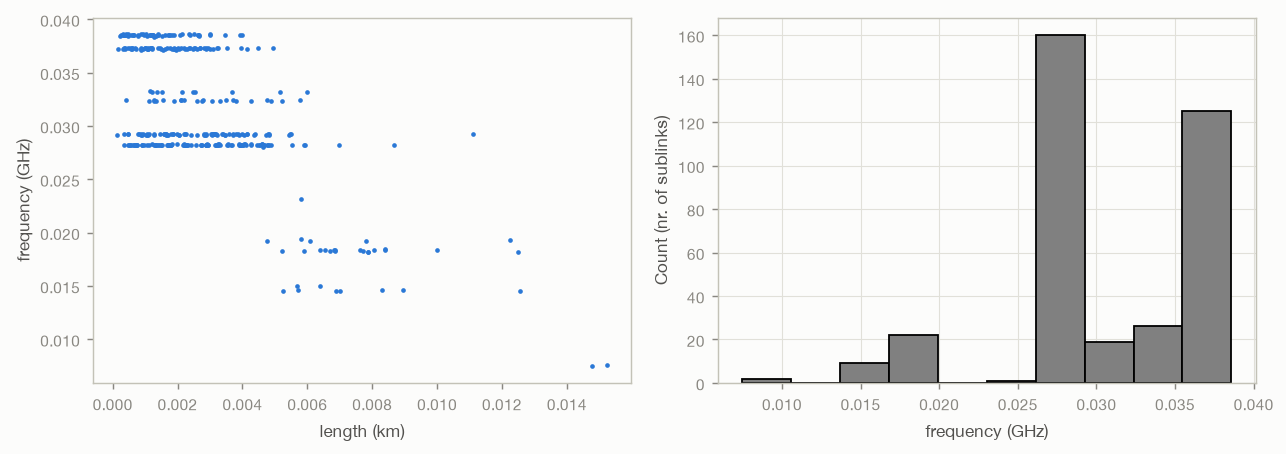

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
plg.plot_metadata.plot_len_vs_freq(cml.length_km, cml.frequency_ghz.isel(sublink_id=0),
                                   ax=axes[0], marker_color=vs.SERIES["stratiform"])
axes[0].set_xlabel("length (km)"); axes[0].set_ylabel("frequency (GHz)")
plg.plot_metadata.plot_distribution(cml.length_km, cml.frequency_ghz.isel(sublink_id=0),
                                    variable="frequency", bins=15, ax=axes[1])
axes[1].set_xlabel("frequency (GHz)")
fig.tight_layout()

## 3. Retrieve rain, step by step

`retrieve_dataset` runs the whole chain on an OpenSense-1.0 dataset and returns
every intermediate, so it can be inspected rather than trusted:

`loss = TSL − RSL` → **wet/dry** → **baseline** from dry samples →
`A_obs = loss − baseline` → **wet-antenna** removed → `R = (A/kL)^(1/α)`

It reads TSL when present (RSL-only networks such as OpenMesh work too),
scales its windows to the sampling interval (10 s here), and matches per-link
metadata to sublinks **by dimension name** - the files store frequency as
(sublink, link) and the signals as (time, sublink, link), and matching them by
position silently gives every link another link's frequency.

In [5]:
default = rt.retrieve_dataset(cml)
print(default.attrs["retrieval"])
default

wet_window=30, wet_threshold_db=0.8, baseline_window=1080, min_attenuation_db=0.1, min_length_km=0.5, waa_model=saturating, waa_max_db=0.5, waa_rate_per_mm_h=0.28, waa_pastorek_a_max_db=14.0, waa_pastorek_zeta=0.55, waa_pastorek_d=0.1, zero_when_dry=False


<xarray.Dataset> Size: 194MB
Dimensions:        (time: 6480, cml_id: 364, sublink_id: 2)
Coordinates: (12/18)
  * sublink_id     (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id         (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
    site_0_lat     (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.65 57.66 57.71
    site_0_lon     (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.12 12.03 12.01
    site_1_lat     (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.66 57.63 57.71
    site_1_lon     (cml_id) float64 3kB 11.99 11.97 11.98 ... 12.14 11.97 11.98
    ...             ...
    x              (cml_id) float64 3kB 6.784e+05 6.773e+05 ... 6.785e+05
    y              (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.4e+06
  * time           (time) datetime64[ns] 52kB 2015-07-28T06:00:00 ... 2015-07...
    frequency      (cml_id, sublink_id) float64 6kB 2.821e+04 ... 2.926e+04
    polarization   (cml_id, sublink_id) <U10 29kB 'vertical' ... 'vertical'
    frequency_ghz  (cml_id, sublink_id) float64 6kB 28.21 29.21 ... 28.25 29.26
Data variables:
    R              (time, cml_id, sublink_id) float64 38MB 0.0 0.0 ... 0.0 0.0
    A_obs          (time, cml_id, sublink_id) float64 38MB 0.0 0.0 ... 0.0 0.0
    A_rain         (time, cml_id, sublink_id) float64 38MB 0.0 0.0 ... 0.0 0.0
    waa            (time, cml_id, sublink_id) float64 38MB 0.0 0.0 ... 0.0 0.0
    baseline       (time, cml_id, sublink_id) float64 38MB 47.0 44.5 ... 49.5
    wet            (time, cml_id, sublink_id) bool 5MB False False ... False
Attributes:
    retrieval:  wet_window=30, wet_threshold_db=0.8, baseline_window=1080, mi...
    loss:       TSL - RSL

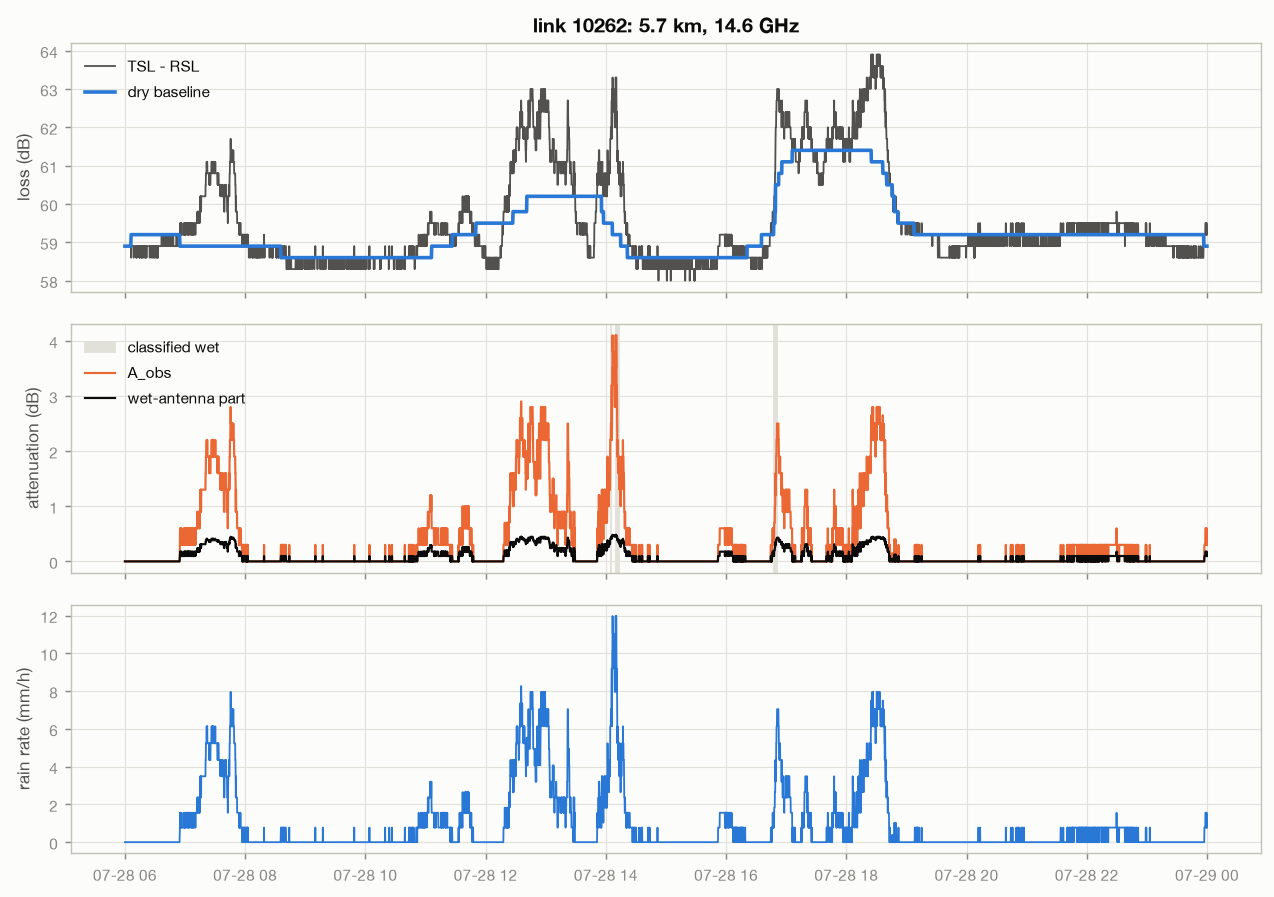

In [6]:
# The example link is chosen by what the *radar* saw along its path, not by the
# CML's own total: ranking links by their own retrieval puts faulty links first.
# Longer than 2 km, because shorter paths amplify noise (see min_length_km), and
# reporting on both sublinks for at least 95% of the day.
radar_path = ev.radar_along_links(radar.R, cml)                     # (time, cml_id)
reporting = default.R.notnull().all("sublink_id").mean("time") > 0.95
link = int(radar_path.sum("time").where((cml.length_km > 2) & reporting).argmax())
one = default.isel(cml_id=link, sublink_id=0)
loss = (cml.tsl - cml.rsl).isel(cml_id=link, sublink_id=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(loss.time, loss, lw=1, color=vs.INK_SECONDARY, label="TSL - RSL")
axes[0].plot(one.time, one.baseline, lw=2, color=vs.SERIES["stratiform"], label="dry baseline")
axes[0].set_ylabel("loss (dB)"); axes[0].legend(loc="upper left")
axes[1].fill_between(one.time, 0, 1, where=one.wet.values, color=vs.GRIDLINE,
                     transform=axes[1].get_xaxis_transform(), label="classified wet")
axes[1].plot(one.time, one.A_obs, lw=1.2, color=vs.SERIES["convective"], label="A_obs")
axes[1].plot(one.time, one.waa, lw=1.2, color=vs.INK_PRIMARY, label="wet-antenna part")
axes[1].set_ylabel("attenuation (dB)"); axes[1].legend(loc="upper left")
axes[2].plot(one.time, one.R, lw=1, color=vs.SERIES["stratiform"])
axes[2].set_ylabel("rain rate (mm/h)")
axes[0].set_title(f"link {int(one.cml_id)}: {float(one.length_km):.1f} km, "
                  f"{float(one.frequency_ghz):.1f} GHz")
fig.tight_layout()

Look at the dry baseline in the top panel: it **climbs during the rain** at
12-14 h and 17-18 h. The rolling-std classifier keys on fluctuation, calls the
steadier parts of the rain dry, and the baseline learns them - so the
retrieval loses exactly the rain it was meant to find. Section 5 fixes this.

## 4. Score it against sensors that do not share its errors

Comparing a link with a radar or a gauge first means putting both on the
same support. `core.opensense.evaluation` wraps the `poligrain` tools for that:

* `radar_along_links` - radar **path-averaged along each link**
  (`poligrain.spatial.GridAtLines`), rather than the link smeared onto the grid
* `closest_gauges` - gauges within 1 km of the link **path**
  (`get_closest_points_to_line`). Called directly with `length` in km, as
  OpenSense files carry it, poligrain's search radius shrinks ~1000x and half
  the matches go missing; the wrapper always uses metres
* `rainfall_metrics` - `poligrain.validation`, with bias over the whole record
  and the 0.1 mm/h threshold used for wet/dry skill (MCC) only

In [7]:
# radar_path was computed in section 3: GridAtLines, (time, cml_id) at 5 min
closest = ev.closest_gauges(cml, gauges, max_distance_m=1000)
gauge_at_links = ev.gauge_series_at_links(ev.aggregate(gauge_rate, "15min"), closest)
print(f"{int(np.isfinite(closest.distance.isel(n_closest=0)).sum())} links have a gauge within 1 km of their path")

def score(per_link, label):
    g = ev.rainfall_metrics(gauge_at_links, ev.aggregate(per_link, "15min"))
    r = ev.rainfall_metrics(radar_path, ev.aggregate(per_link, "5min"))
    return {"retrieval": label, "gauge ratio": g["ratio"], "gauge r": g["r"],
            "gauge MCC": g["mcc"], "radar r": r["r"], "radar MCC": r["mcc"]}

reference = cml.R.mean("sublink_id")          # the OpenSense community's own retrieval
rows = [score(rt.combine_sublinks(default).R, "this chain, defaults"),
        score(reference, "OpenSense reference R")]
import pandas as pd
pd.DataFrame(rows).set_index("retrieval").round(3)

86 links have a gauge within 1 km of their path


,gauge ratio,gauge r,gauge MCC,radar r,radar MCC
retrieval,,,,,
"this chain, defaults",1.825,0.652,0.409,0.405,0.413
OpenSense reference R,0.930,0.663,0.621,0.394,0.639


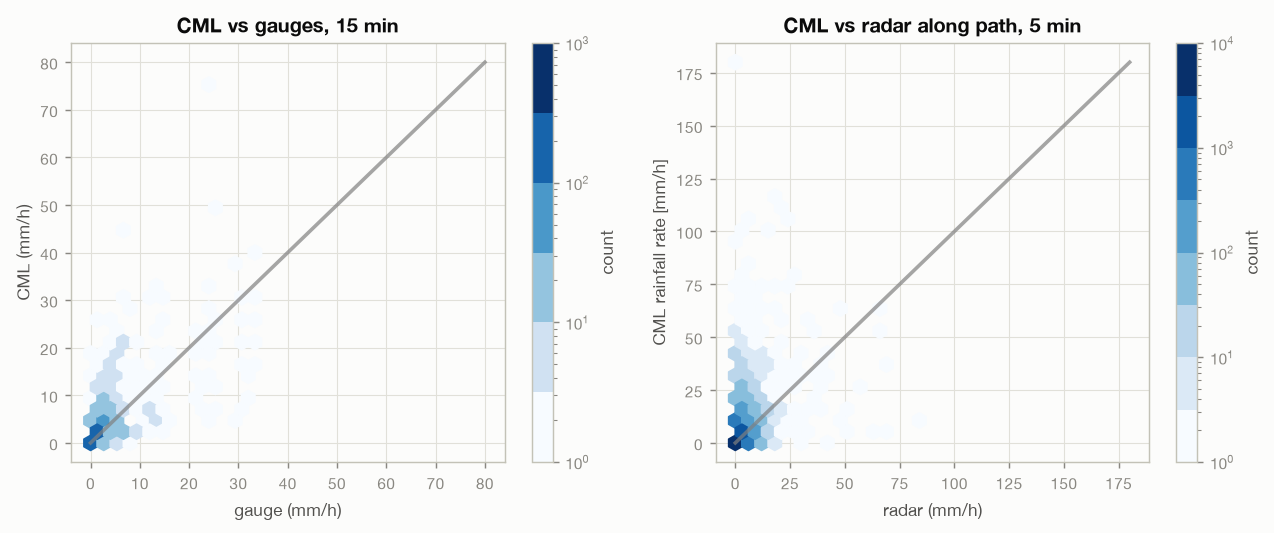

In [8]:
per_link = rt.combine_sublinks(default).R
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
a, b = xr.align(gauge_at_links, ev.aggregate(per_link, "15min").transpose(*gauge_at_links.dims))
plg.validation.plot_hexbin(a.values, b.values, ref_thresh=0.1, est_thresh=0.1, ax=axes[0],
                           cmap="Blues", gridsize=30)
axes[0].set_title("CML vs gauges, 15 min"); axes[0].set_xlabel("gauge (mm/h)"); axes[0].set_ylabel("CML (mm/h)")
a, b = xr.align(radar_path, ev.aggregate(per_link, "5min").transpose(*radar_path.dims))
plg.validation.plot_hexbin(a.values, b.values, ref_thresh=0.1, est_thresh=0.1, ax=axes[1],
                           cmap="Blues", gridsize=30)
axes[1].set_title("CML vs radar along path, 5 min"); axes[1].set_xlabel("radar (mm/h)")
fig.tight_layout()

The default chain has good *skill* (correlation) and the wrong *magnitude*: it
reads about twice the gauges. That is what the next section fixes.

## 5. Improve the algorithm

Two steps of the chain have established alternatives in the OpenSense
ecosystem:

* **wet/dry** - the nearby-link method of Overeem et al. (2016), via
  `pycomlink`: a link is wet when it *and* its neighbours drop together, so a
  steady stratiform signal is no longer mistaken for dry weather and learned
  into the baseline (`core.opensense.wet_dry.nearby_links`)
* **wet-antenna attenuation** - the Pastorek et al. (2021) model, via
  `pycomlink` (`waa_model="pastorek2021"`)

Over the full 8 days (`src/retrieval_benchmark.py`) neither helps reliably on
its own: a better mask alone *increases* the over-read, because the old mask
was leaking rain into the baseline, and that leak had been hiding the missing
wet-antenna correction. Together they give the best correlation and wet/dry
skill of every variant, including the reference, and the most stable
day-to-day ratio. Here is the same comparison on this one day.

The nearby method needs 24 hours of history for its reference level, so the
mask is computed on the full 8 days and then cut to the window.

In [9]:
full = example_data.load("openmrg", "8d", components=("cml",), verbose=False)["cml"]
mask_8d = wet_dry.nearby_links(full)
mask = mask_8d.sel(time=cml.time)
del full
print(f"nearby-link mask decided {float(np.isfinite(mask).mean()) * 100:.0f}% of samples; "
      f"the rest fall back to rolling-std")

nearby-link mask decided 100% of samples; the rest fall back to rolling-std


In [10]:
cfg = rt.RetrievalConfig.for_interval(10, waa_model="pastorek2021")
improved = rt.retrieve_dataset(cml, cfg, wet=wet_dry.fill_undecided(mask, cml))

rows.insert(1, score(rt.combine_sublinks(improved).R, "nearby wet/dry + Pastorek WAA"))
pd.DataFrame(rows).set_index("retrieval").round(3)

,gauge ratio,gauge r,gauge MCC,radar r,radar MCC
retrieval,,,,,
"this chain, defaults",1.825,0.652,0.409,0.405,0.413
nearby wet/dry + Pastorek WAA,0.729,0.699,0.651,0.427,0.592
OpenSense reference R,0.930,0.663,0.621,0.394,0.639


Text(0.5, 1.0, 'link 10262, 5-minute means')

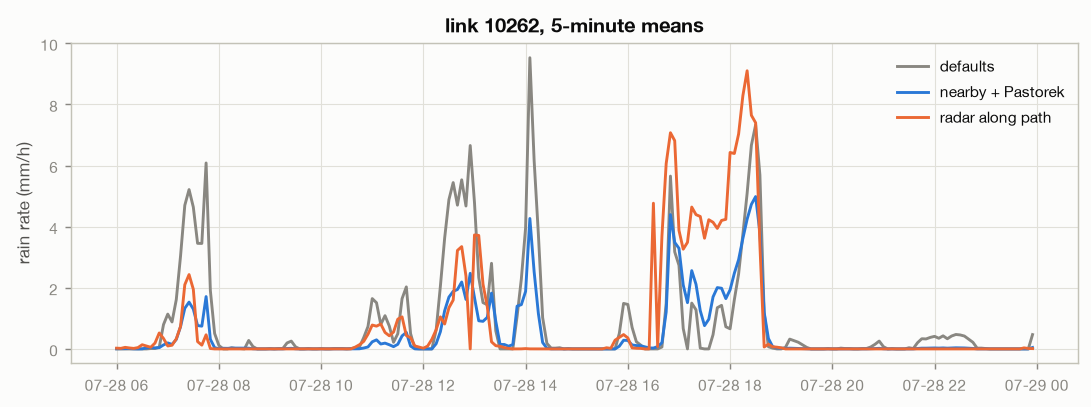

In [11]:
wettest = one.cml_id.item()
fig, ax = plt.subplots(figsize=(10, 3.2))
for ds_, label, color in ((default, "defaults", vs.INK_MUTED),
                          (improved, "nearby + Pastorek", vs.SERIES["stratiform"])):
    s = ev.aggregate(rt.combine_sublinks(ds_).R.sel(cml_id=wettest), "5min")
    ax.plot(s.time, s, lw=1.6, color=color, label=label)
rp = radar_path.sel(cml_id=wettest)
ax.plot(rp.time, rp, lw=1.6, color=vs.SERIES["convective"], label="radar along path")
ax.set_ylabel("rain rate (mm/h)"); ax.legend(loc="upper right")
ax.set_title(f"link {wettest}, 5-minute means")

## 6. Map it

Per-link rain rates at one timestep become a field with `mergeplg`, through the
thin wrapper in `src/merging.py` that gives every method the same call.
Line-aware CML-only IDW, and an additive merge of radar and CML - the method
the synthetic benchmark ranks most reliable.

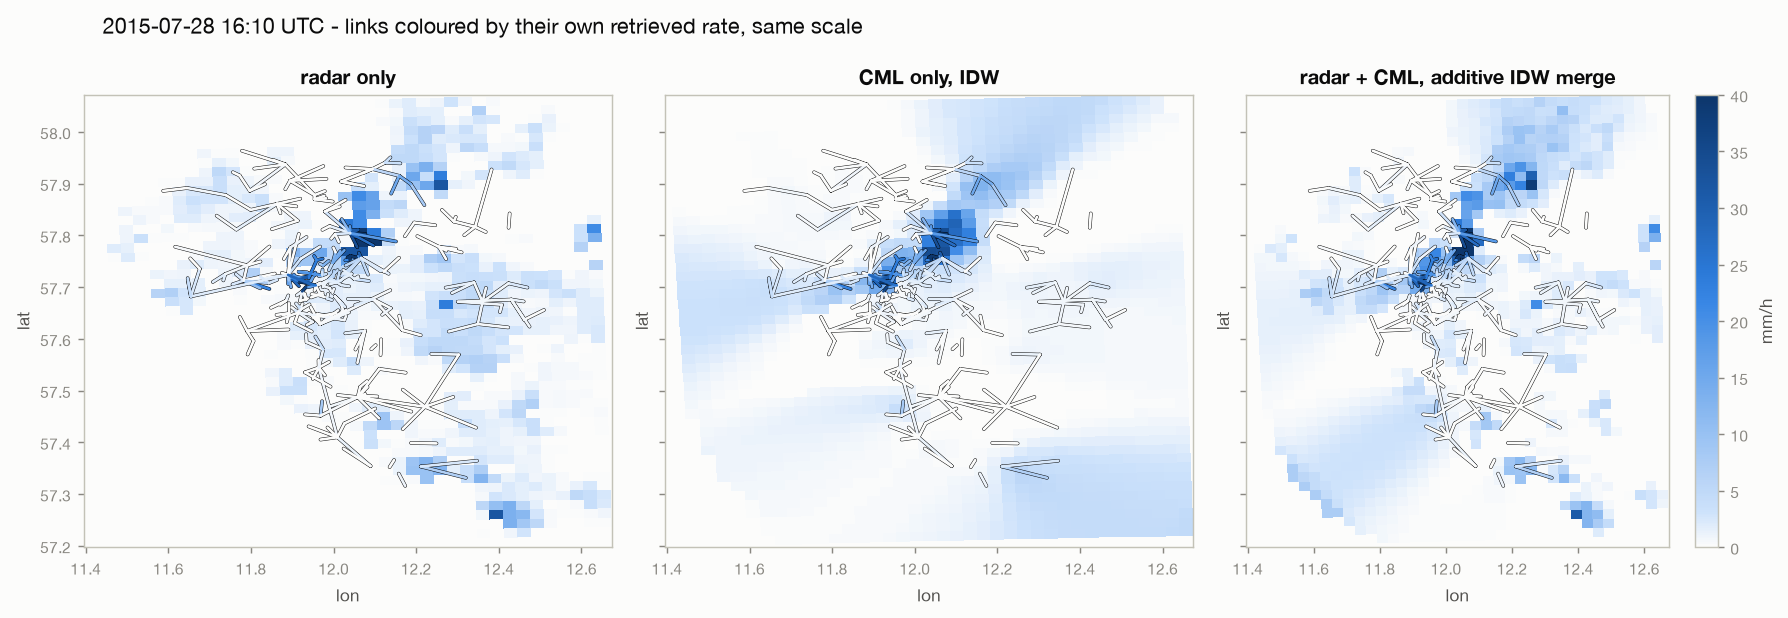

In [12]:
per_link_5 = ev.aggregate(rt.combine_sublinks(improved).R, "5min")
# the wettest 5 minutes on the link network - the radar's peak is off to the north
t = str(per_link_5.time.values[int(per_link_5.sum("cml_id").argmax())])
da_rad = radar.R.sel(time=t)
da_cml = per_link_5.sel(time=t)
da_cml = da_cml.isel(cml_id=np.isfinite(da_cml.values))

methods = {m.key: m for m in merging.METHODS}
fields = {"radar only": da_rad,
          "CML only, IDW": merging.run(methods["cml_idw"], da_rad, da_cml),
          "radar + CML, additive IDW merge": merging.run(methods["merge_idw_add"], da_rad, da_cml)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
for ax, (name, f) in zip(axes, fields.items()):
    f = f.assign_coords(lon=radar.lon, lat=radar.lat)
    plg.plot_map.plot_plg(da_grid=f, da_cmls=da_cml, use_lon_lat=True, ax=ax,
                          vmin=0, vmax=40, cmap=vs.CMAP_RAIN, add_colorbar=ax is axes[-1],
                          colorbar_label="mm/h", kwargs_cmls_plot=dict(line_width=1.5))
    ax.set_title(name)
fig.suptitle(f"{t[:16].replace('T', ' ')} UTC - links coloured by their own retrieved rate, same scale",
             x=0.06, ha="left")
fig.tight_layout()

## Where to go from here

| to | run |
|---|---|
| rank retrieval variants over all 8 days | `python projects/opensense_pipeline/src/retrieval_benchmark.py` |
| check the chain against the OpenSense reference | `python projects/opensense_pipeline/src/validate_retrieval.py --offline` |
| rank merge methods on synthetic truth, then real data | `python projects/opensense_pipeline/src/run_pipeline.py --source example` |
| radar vs CML through eight events, rain and snow | `python projects/opensense_pipeline/src/compare_radar_cml.py --all` |
| the unit tests for everything used above | `python -m pytest` |

Everything above is `core.opensense`: `example_data` and `fetch` to pull,
`conventions` to normalize, `retrieval` and `wet_dry` to retrieve, `evaluation`
to score. Swapping `"openmrg"` for `"openrainer"` runs the same notebook on
Italy; OpenMesh (NYC) is RSL-only and multi-band, see `src/ingest_openmesh.py`.